In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import time
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from torchvision.utils import make_grid

In [41]:
# set the device, default to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [42]:
# We keep this as global variable we will reference throughout this notebook
config = {
    'batch_size': 64,
    'n_channels': 1, # for MNIST
    'n_epochs': 10,
    'n_hiddens': 128,
    'n_residual_hiddens': 32,
    'n_residual_layers': 2,
    'embedding_dim': 16, # latent dimension
    'n_embeddings': 128, # codebook entries count
    'beta': 0.25,
    'learning_rate': 1e-3, # 3e-4
    'plot_epochs': 5, # plto every plot_epochs of training
    'dataset': 'MNIST',
    'data_dir': 'data/',
    'save_dir': 'results/',
    }

print(f'Model checkpoints and results will be saved in {config["save_dir"]}')
print(f'Data will be saved in {config["data_dir"]}')

if not os.path.exists(config["save_dir"]):
    os.makedirs(config["save_dir"])

if not os.path.exists(config["data_dir"]):
    os.makedirs(config["data_dir"])

Model checkpoints and results will be saved in results/
Data will be saved in data/


In [43]:
def save_model_and_results(model, results):
    timestamp = int(time.time())
    save_path = os.path.join(config["save_dir"], f'vqvae_{config["dataset"]}_{timestamp}.pth')
    print(f"Saving checkpoint in: {save_path}")
    torch.save({
        'model': model.state_dict(),
        'results': results,
        'config': config
    }, save_path)

In [44]:
# Plotting utils
def display_image_grid(x):
    x = make_grid(x.cpu().detach() + 0.5) # + 0.5 to undo normalization in loading (for mnist: transforms.Normalize((0.5), (0.5))]) )
    x = x.numpy()
    fig = plt.imshow(np.transpose(x, (1,2,0)).squeeze(), interpolation='nearest', cmap='gray')
    fig.axes.get_xaxis().set_visible(False)
    fig.axes.get_yaxis().set_visible(False)

def display_image_grid_side_by_side(x, xhat, codebook, epoch=None):
    # Undo normalization from Normalize((0.5,), (0.5,))
    x = make_grid(x.cpu().detach() + 0.5)
    x = x.numpy()

    xhat = make_grid(xhat.cpu().detach() + 0.5)
    xhat = xhat.numpy()

    fig, axs = plt.subplots(ncols=3, figsize=(18, 12), squeeze=False)

    # True image grid
    axs[0, 0].imshow(
        np.transpose(x, (1, 2, 0)).squeeze(),
        interpolation="nearest",
        cmap="gray"
    )
    axs[0, 0].set_aspect("equal")
    axs[0, 0].axis("off")
    axs[0, 0].set_title("True")

    # Codebook / encoded representation
    title_codebook = "Encoded image codebooks" if epoch is None else f"Codebook (Epoch {epoch})"
    axs[0, 1].imshow(
        codebook.cpu().detach().numpy(),
        interpolation="nearest",
        cmap="gray"
    )
    axs[0, 1].set_aspect("equal")
    axs[0, 1].axis("off")
    axs[0, 1].set_title(title_codebook)

    # Generated image grid
    title_generated = "Generated" if epoch is None else f"Generated (Epoch {epoch})"
    axs[0, 2].imshow(
        np.transpose(xhat, (1, 2, 0)).squeeze(),
        interpolation="nearest",
        cmap="gray"
    )
    axs[0, 2].set_aspect("equal")
    axs[0, 2].axis("off")
    axs[0, 2].set_title(title_generated)

    plt.subplots_adjust(wspace=0.05, hspace=0.1)
    plt.show()

In [45]:
# Make a class for our data... hopefull will help with scalability
class VQVAE_Data():
    def __init__(self, dataset, data_dir, batch_size):
        self.dataset = dataset
        self.data_dir = data_dir
        self.batch_size = batch_size
        # initial values, will be set by this class's methods
        self.train_data = None
        self.val_data = None
        # variances of the training data
        self.train_data_vars = None

    def _load_cifar10(self):
        save_dir = os.path.join(self.data_dir, "cifar10")
        # https://pytorch.org/vision/main/generated/torchvision.transforms.Normalize.html
        transforms_cifar10 = transforms.Compose([transforms.ToTensor(),
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        train = datasets.CIFAR10(root=save_dir, train=True, download=True,
                                transform=transforms_cifar10)
        val = datasets.CIFAR10(root=save_dir, train=False, download=True,
                              transform=transforms_cifar10)
        return train, val

    def _load_mnist(self):
        save_dir = os.path.join(self.data_dir, "mnist")
        transforms_mnist = transforms.Compose([transforms.ToTensor(),
                                              transforms.Normalize((0.5), (0.5))])
        train = datasets.MNIST(root=save_dir, train=True, download=True,
                              transform=transforms_mnist)
        val = datasets.MNIST(root=save_dir, train=False, download=True,
                              transform=transforms_mnist)
        return train, val

    def _dataloaders(self):
        train_loader = DataLoader(self.train_data,
                                  batch_size=self.batch_size,
                                  shuffle=True,
                                  drop_last=True,
                                  pin_memory=True)
        val_loader = DataLoader(self.val_data,
                                batch_size=self.batch_size,
                                shuffle=True,
                                drop_last=True,
                                pin_memory=True)
        return train_loader, val_loader

    def build_all(self):
        '''
        Loads and stores the data, builds the dataloader, stores variances of training data
        Returns train_loader and val_loader
        '''
        if self.dataset == 'CIFAR10':
            train_data, val_data = self._load_cifar10()
            train_data_vars = np.var(train_data.data / 255.0) # note: if this messes up, we need to reload the data or compute from dir

        elif self.dataset == 'MNIST':
            # note this comes as Torch tensor
            train_data, val_data = self._load_mnist()
            train_data_vars = np.var(train_data.data.numpy()) # note: if this messes up, we need to reload the data or compute from dir
        else:
            raise ValueError("Only CIFAR10 and MNIST datasets have been implemented so far.")

        self.train_data = train_data
        self.val_data = val_data
        self.train_data_vars = train_data_vars

        train_loader, val_loader = self._dataloaders()
        return train_loader, val_loader

    def get_train_variances(self):
        return self.train_data_vars

    def get_train_data(self):
        return self.train_data

    def get_val_data(self):
        return self.val_data

    def __call__(self):
        return self.build_all()

In [46]:
# build dataloaders
vqvae_data = VQVAE_Data(config["dataset"], config["data_dir"], config["batch_size"])
train_loader, val_loader = vqvae_data.build_all()

In [47]:
# We can use this to (optionally) normalize our reconstruction loss
train_data_vars = vqvae_data.get_train_variances()
print(train_data_vars)

6172.850482291342


In [48]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.ReLU(True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.ReLU(True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.stack = nn.ModuleList(
            [ResidualLayer(in_dim, h_dim, res_h_dim)]*n_res_layers)

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [49]:
class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, self.embedding.weight.t())

        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # get quantized latent vectors
        z_q = torch.matmul(min_encodings, self.embedding.weight).view(z.shape)

        # compute loss for embedding
        loss = torch.mean((z_q.detach()-z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients
        z_q = z + (z_q - z).detach()

        # perplexity
        e_mean = torch.mean(min_encodings, dim=0)
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        z_q = z_q.permute(0, 3, 1, 2).contiguous()
        
        codebook = self.embedding.weight

        return (
            loss, 
            z_q, 
            perplexity, 
            min_encodings,
            min_encoding_indices,
            codebook
        )

In [50]:
class Encoder(nn.Module):
    """
    This is the q_theta (z|x) network. Given a data sample x q_theta
    maps to the latent space x -> z.

    For a VQ VAE, q_theta outputs parameters of a categorical distribution.

    Inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack

    """

    def __init__(self, in_dim, h_dim, n_res_layers, res_h_dim):
        super(Encoder, self).__init__()
        kernel = 4
        stride = 2
        self.conv_stack = nn.Sequential(
            nn.Conv2d(in_dim, h_dim // 2, kernel_size=kernel,
                      stride=stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim // 2, h_dim, kernel_size=kernel,
                      stride=stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim, h_dim, kernel_size=kernel-1,
                      stride=stride-1, padding=1),
            ResidualStack(
                h_dim, h_dim, res_h_dim, n_res_layers)
        )

    def forward(self, x):
        return self.conv_stack(x)


In [51]:
class Decoder(nn.Module):
    """
    This is the p_phi (x|z) network. Given a latent sample z p_phi
    maps back to the original space z -> x.

    Inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack

    """

    def __init__(self, in_dim, h_dim, n_res_layers, res_h_dim):
        super(Decoder, self).__init__()
        kernel = 4
        stride = 2

        self.inverse_conv_stack = nn.Sequential(
            nn.ConvTranspose2d(
                in_dim, h_dim, kernel_size=kernel-1, stride=stride-1, padding=1),
            ResidualStack(h_dim, h_dim, res_h_dim, n_res_layers),
            nn.ConvTranspose2d(h_dim, h_dim // 2,
                               kernel_size=kernel, stride=stride, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(h_dim//2, config["n_channels"], kernel_size=kernel, # set num_channels
                               stride=stride, padding=1)
        )

    def forward(self, x):
        return self.inverse_conv_stack(x)

In [52]:
class VQVAE(nn.Module):
    def __init__(self, h_dim, res_h_dim, n_res_layers,
                 n_embeddings, embedding_dim, beta, save_img_embedding_map=False):
        super(VQVAE, self).__init__()
        # encode image into continuous latent space
        self.encoder = Encoder(config["n_channels"], h_dim, n_res_layers, res_h_dim) # set num_channels
        self.pre_quantization_conv = nn.Conv2d(
            h_dim, embedding_dim, kernel_size=1, stride=1)
        # pass continuous latent vector through discretization bottleneck
        self.vector_quantization = VectorQuantizer(
            n_embeddings, embedding_dim, beta)
        # decode the discrete latent representation
        self.decoder = Decoder(embedding_dim, h_dim, n_res_layers, res_h_dim)

        if save_img_embedding_map:
            self.img_to_embedding_map = {i: [] for i in range(n_embeddings)}
        else:
            self.img_to_embedding_map = None

    def forward(self, x, verbose=False): # generate

        z_e = self.encoder(x)

        z_e = self.pre_quantization_conv(z_e)
        embedding_loss, z_q, perplexity, _, _, codebook = self.vector_quantization(
            z_e)
        x_hat = self.decoder(z_q)

        if verbose:
            print('original data shape:', x.shape)
            print('encoded data shape:', z_e.shape)
            print('recon data shape:', x_hat.shape)
            assert False

        return embedding_loss, x_hat, perplexity, z_e, codebook

In [53]:
model = VQVAE(config["n_hiddens"], config["n_residual_hiddens"], config["n_residual_layers"],
              config["n_embeddings"], config["embedding_dim"], config["beta"]).to(device)

In [54]:
model

VQVAE(
  (encoder): Encoder(
    (conv_stack): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): ResidualStack(
        (stack): ModuleList(
          (0-1): 2 x ResidualLayer(
            (res_block): Sequential(
              (0): ReLU(inplace=True)
              (1): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (2): ReLU(inplace=True)
              (3): Conv2d(32, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
            )
          )
        )
      )
    )
  )
  (pre_quantization_conv): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
  (vector_quantization): VectorQuantizer(
    (embedding): Embedding(128, 16)
  )
  (decoder): Decoder(
    (inverse_conv_stack): Sequential(
      (0): Con

In [55]:
# Build optimizer
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"], amsgrad=True)

Average test loss: 0.82242


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8611382..1.9783447].


Epoch: 1 Avg train loss: 0.09229 Avg perplexity: 30.03348159790039
Latent vector encoder output size: torch.Size([7, 7])
Codebook size: num_embeddings=128, latent_dim=16


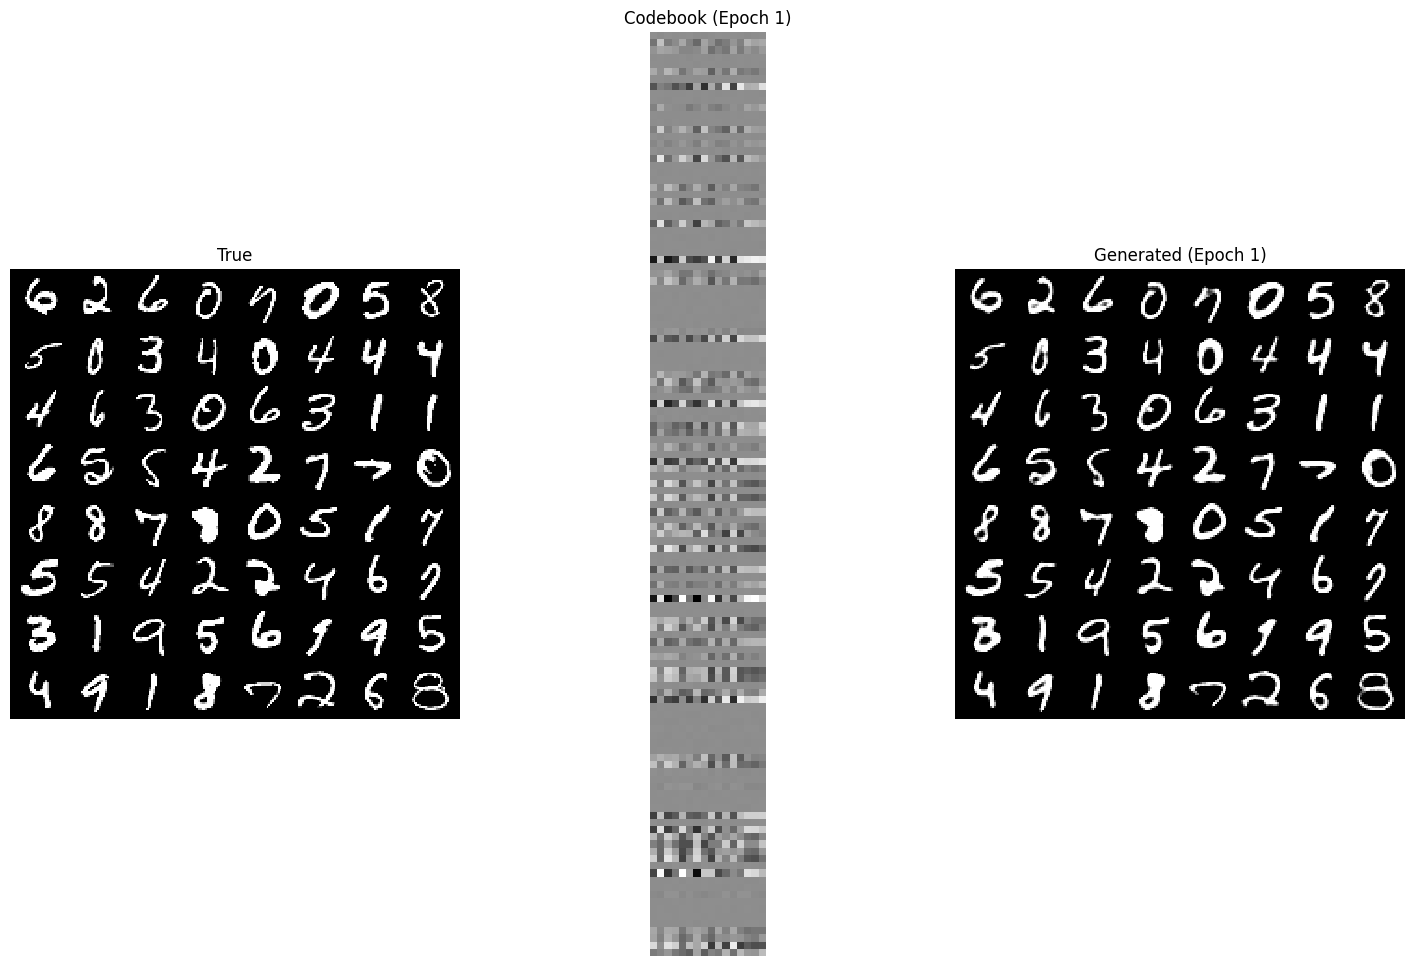

Average test loss: 0.02961
Epoch: 2 Avg train loss: 0.02546 Avg perplexity: 41.596004486083984
Average test loss: 0.02204
Epoch: 3 Avg train loss: 0.02110 Avg perplexity: 42.56283187866211
Average test loss: 0.01948
Epoch: 4 Avg train loss: 0.01942 Avg perplexity: 41.72597122192383
Average test loss: 0.01834


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7820827..1.7742957].


Epoch: 5 Avg train loss: 0.01852 Avg perplexity: 40.519718170166016
Latent vector encoder output size: torch.Size([7, 7])
Codebook size: num_embeddings=128, latent_dim=16


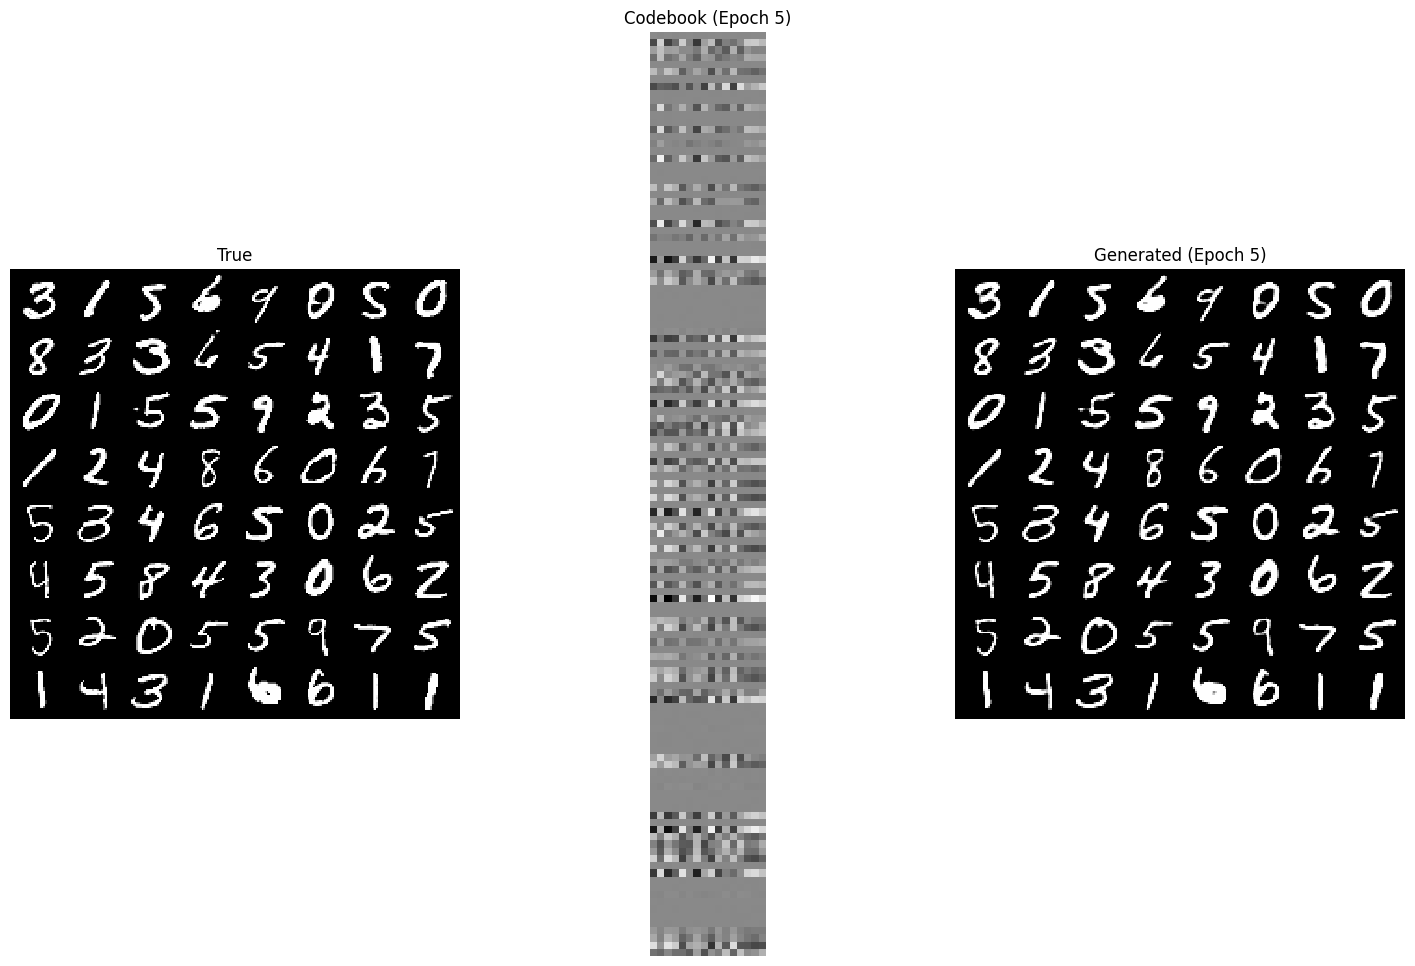

Average test loss: 0.01786
Epoch: 6 Avg train loss: 0.01784 Avg perplexity: 40.1592903137207
Average test loss: 0.01723
Epoch: 7 Avg train loss: 0.01736 Avg perplexity: 39.88762283325195
Average test loss: 0.01682
Epoch: 8 Avg train loss: 0.01705 Avg perplexity: 39.6059455871582
Average test loss: 0.01666
Epoch: 9 Avg train loss: 0.01678 Avg perplexity: 39.37929153442383
Average test loss: 0.01634


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5..1.5].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76706123..1.737282].


Epoch: 10 Avg train loss: 0.01653 Avg perplexity: 39.13468551635742
Latent vector encoder output size: torch.Size([7, 7])
Codebook size: num_embeddings=128, latent_dim=16


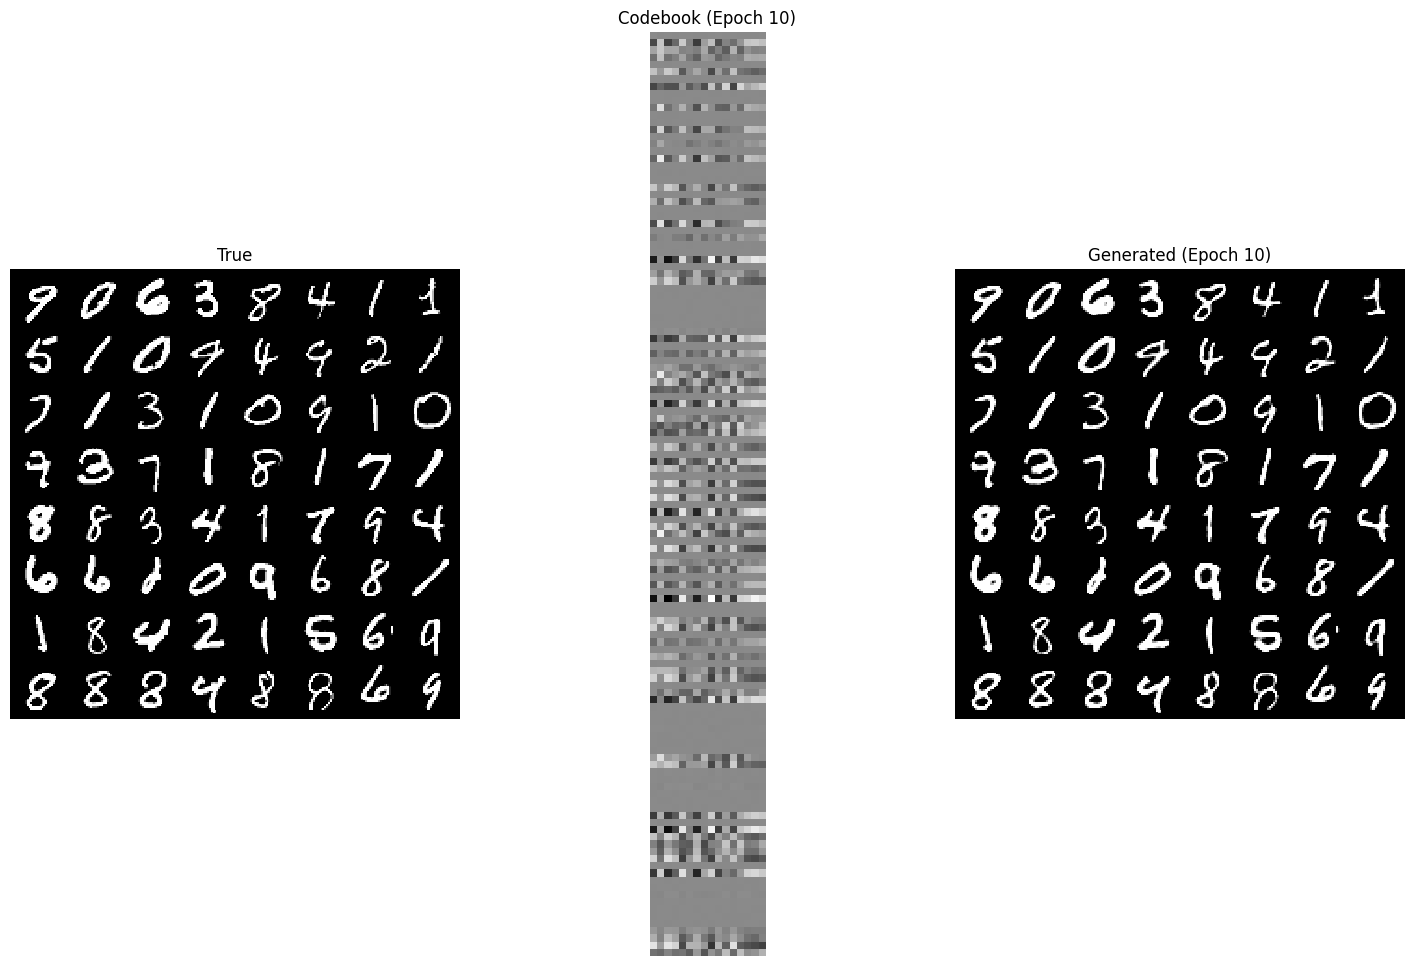

Average test loss: 0.01650
Saving checkpoint in: results/vqvae_MNIST_1779112082.pth
CPU times: user 13min 50s, sys: 469 ms, total: 13min 50s
Wall time: 59 s


In [56]:
%%time
# Initialize dict to store results
results = {
    'n_updates': 0,
    'train_recon_errors': [], # start of train results
    'train_perplexities': [],
    'train_losses': [],
    'avg_train_loss_epochs': [],
    # 'test_recon_errors': [], # start of test results
    # 'test_perplexities': [],
    'test_losses': [],
    'avg_test_loss_epochs': [],
}

iters_train = len(train_loader)
iters_test = len(val_loader)

# TODO: generate_images functionality, save avg epoch and per iterations results, implement testing loop

for epoch in range(config["n_epochs"] + 1):
    # Training
    if epoch > 0:  # test untrained net first
        # Set model to training mode
        model.train()
        train_loss = 0.
        for i, (x, _) in enumerate(train_loader): # iters_train
            x = x.to(device)
            # ===================forward=====================
            embedding_loss, x_hat, perplexity, z_e, codebook = model(x)
            recon_loss = torch.mean((x_hat - x)**2) #/ train_data_vars # NOTE: this is pretty interesting, not standard afaik
            loss = recon_loss + embedding_loss
            train_loss += loss #.item()

            # ===================backward====================
            # zero out the previous gradients to prevent accumulation
            optimizer.zero_grad()
            # backpropagate
            loss.backward()
            optimizer.step()
            # scheduler.step(epoch + i / iters_train)

            results["train_recon_errors"].append(recon_loss.cpu().detach().numpy())
            results["train_perplexities"].append(perplexity.cpu().detach().numpy())
            results["train_losses"].append(loss.cpu().detach().numpy())

        results["n_updates"] += iters_train
        avg_train_loss = train_loss / iters_train # len(train_loader.dataset)
        avg_perplexity = np.mean(results["train_perplexities"][-iters_train:])
        results["avg_train_loss_epochs"].append(avg_train_loss)
        print(f'Epoch: {epoch} Avg train loss: {avg_train_loss:.5f} Avg perplexity: {avg_perplexity}')

        # display images (include plot after first training epoch, epoch 1)
        if epoch == 1 or epoch % config["plot_epochs"] == 0:
            print(f"Latent vector encoder output size: {z_e[0][0].shape}")
            
            num_embeddings, latent_dim = codebook.shape
            print(f"Codebook size: num_embeddings={num_embeddings}, latent_dim={latent_dim}")
            
            
            display_image_grid_side_by_side(x, x_hat, codebook, epoch=epoch)
            plt.show()

    # Testing (Validation)
    with torch.no_grad():
        model.eval()
        test_loss = 0.
        # image, label
        for x_test, y_test in val_loader:
            x_test = x_test.to(device)
            # ===================forward=====================
            embedding_loss, x_hat_test, perplexity, z_e, codebook = model(x_test)
            recon_loss = torch.mean((x_hat_test - x_test)**2) #/ train_data_vars # NOTE: this is pretty interesting, not standard afaik
            loss = recon_loss + embedding_loss
            test_loss += loss #.item()
            
            
            # results["test_recon_errors"].append(recon_loss.cpu().detach().numpy())
            # results["test_perplexities"].append(perplexity.cpu().detach().numpy())
            results["test_losses"].append(loss.cpu().detach().numpy())

    avg_test_loss = test_loss / iters_test # len(val_loader.dataset)
    results["avg_test_loss_epochs"].append(avg_test_loss)
    print(f'Average test loss: {avg_test_loss:.5f}')

# save model and results
save_model_and_results(model, results)

In [57]:
def load_model(checkpoint_path):
    if torch.cuda.is_available():
        checkpoint = torch.load(checkpoint_path)
    else: # CPU
        checkpoint = torch.load(checkpoint_path, map_location=lambda storage, loc: storage)

    results = checkpoint["results"]
    config = checkpoint["config"]

    model = VQVAE(config['n_hiddens'], config['n_residual_hiddens'],
                  config['n_residual_layers'], config['n_embeddings'],
                  config['embedding_dim'], config['beta']).to(device)

    model.load_state_dict(checkpoint['model'])

    return model, config, results


from scipy.signal import savgol_filter

def plot_metrics(results):
    recon_errors = savgol_filter(results["train_recon_errors"], 19, 5)
    perplexities = savgol_filter(results["train_perplexities"], 19, 5)
    loss_vals = savgol_filter(results["train_losses"], 19, 5)


    f = plt.figure(figsize=(16,4))
    ax = f.add_subplot(1,3,2)
    ax.plot(recon_errors)
    ax.set_yscale('log')
    ax.set_title('Reconstruction Error')
    ax.set_xlabel('iteration')

    ax = f.add_subplot(1,3,3)
    ax.plot(perplexities)
    ax.set_title('Average codebook usage (perplexity).')
    ax.set_xlabel('iteration')

    ax = f.add_subplot(1,3,1)
    ax.plot(loss_vals)
    ax.set_yscale('log')
    ax.set_title('Overall Loss')
    ax.set_xlabel('iteration')

def reconstruct(data_loader, model):
    (x, _) = next(iter(data_loader))
    x = x.to(device)
    vq_encoder_output = model.pre_quantization_conv(model.encoder(x))
    _, z_q, _, _,e_indices = model.vector_quantization(vq_encoder_output)

    x_recon = model.decoder(z_q)
    return x,x_recon, z_q, e_indices

In [58]:
# it's good practice to save your models, so we do that and load from checkpoint
# checkpoint_path = 'results/vqvae_MNIST_1779105527.pth'
# model, config, results = load_model(checkpoint_path)

In [59]:
%ls results

vqvae_MNIST_1779104354.pth  vqvae_MNIST_1779109388.pth
vqvae_MNIST_1779104802.pth  vqvae_MNIST_1779109823.pth
vqvae_MNIST_1779105069.pth  vqvae_MNIST_1779110769.pth
vqvae_MNIST_1779105211.pth  vqvae_MNIST_1779110922.pth
vqvae_MNIST_1779105527.pth  vqvae_MNIST_1779112082.pth


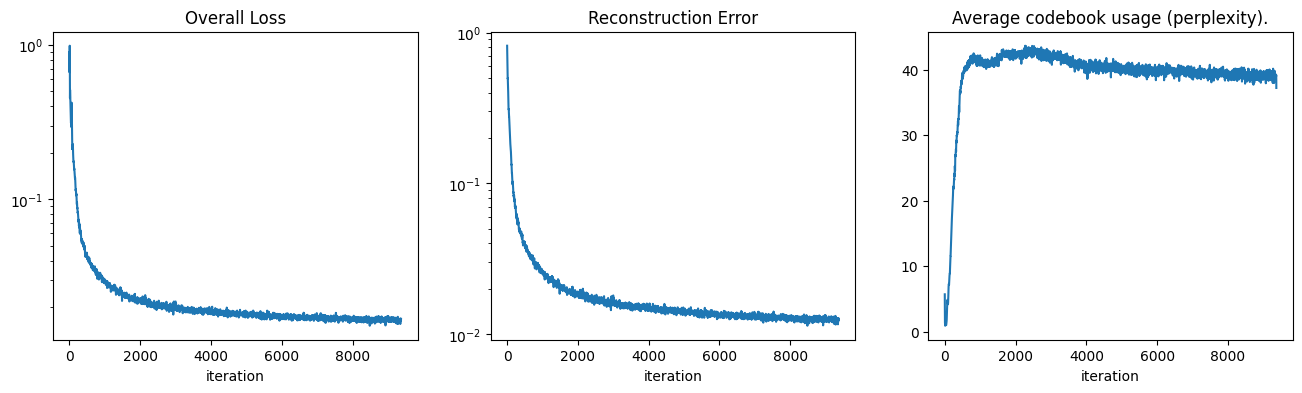

In [60]:
plot_metrics(results)